Epoch 1, Train Loss: 0.00245273, Val Loss: 0.06261894
Epoch 2, Train Loss: 0.00128055, Val Loss: 0.05411933
Epoch 3, Train Loss: 0.00122094, Val Loss: 0.01614925
Epoch 4, Train Loss: 0.00112709, Val Loss: 0.01113158
Epoch 5, Train Loss: 0.00103235, Val Loss: 0.06055455
Epoch 6, Train Loss: 0.00091565, Val Loss: 0.06261894
Epoch 7, Train Loss: 0.00085305, Val Loss: 0.06261894
Epoch 8, Train Loss: 0.00077844, Val Loss: 0.06261894
Epoch 9, Train Loss: 0.00078840, Val Loss: 0.06261894
Epoch 10, Train Loss: 0.00079226, Val Loss: 0.06261894
Epoch 11, Train Loss: 0.00063076, Val Loss: 0.06261894
Epoch 12, Train Loss: 0.00060970, Val Loss: 0.06261894
Epoch 13, Train Loss: 0.00067345, Val Loss: 0.06261894
Epoch 14, Train Loss: 0.00065772, Val Loss: 0.06261894
Epoch 15, Train Loss: 0.00071004, Val Loss: 0.06261894
Epoch 16, Train Loss: 0.00064560, Val Loss: 0.06261894
Epoch 17, Train Loss: 0.00065136, Val Loss: 0.06261894
Epoch 18, Train Loss: 0.00057886, Val Loss: 0.06261894
Epoch 19, Train Los

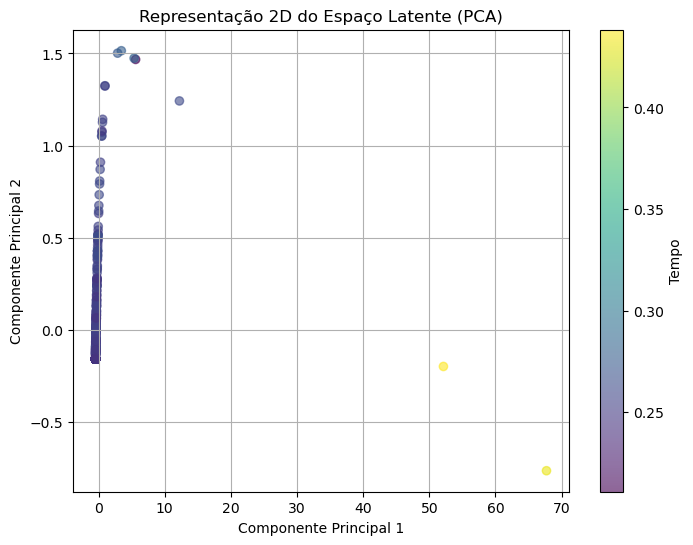

ValueError: All arrays must be of the same length

In [4]:
# %% [markdown]
# # Autoencoder for Mass Flow Data Analysis
# 
# This notebook implements an autoencoder to analyze mass flow data, extract latent representations, and evaluate reconstruction performance.

# %%
# Cell 1: Import all required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path

# %%
# Cell 2: Data preparation function
def dividir_dados(caminho_arquivo):
    caminho_arquivo = Path(caminho_arquivo)
    
    if not caminho_arquivo.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_arquivo}")

    df = pd.read_csv(caminho_arquivo, skiprows=1, header=None)
    tempo = df.iloc[:, 0].values.astype(np.float32)  # Extraindo a coluna de tempo
    dados = df.iloc[:, 1].values.astype(np.float32)
    
    # Dividindo os dados de forma sequencial
    tamanho_treino = int(len(dados) * 0.75)
    treino_tempo = tempo[:tamanho_treino]
    treino_dados = dados[:tamanho_treino]
    validacao_tempo = tempo[tamanho_treino:]
    validacao_dados = dados[tamanho_treino:]
    
    # Convertendo para tensores do PyTorch e ajustando o formato
    treino_tempo = torch.tensor(treino_tempo).unsqueeze(1)  # Formato (n, 1)
    treino_dados = torch.tensor(treino_dados).unsqueeze(1)  # Formato (n, 1)
    validacao_tempo = torch.tensor(validacao_tempo).unsqueeze(1)  # Formato (n, 1)
    validacao_dados = torch.tensor(validacao_dados).unsqueeze(1)  # Formato (n, 1)
    
    return {
        "x_train": treino_dados,
        "t_train": treino_tempo,
        "x_val": validacao_dados,
        "t_val": validacao_tempo
    }

# %%
# Cell 3: Base Model Class
class BaseModel(nn.Module):
    def __init__(self, **kwargs):
        super(BaseModel, self).__init__()
        self.model = None  # Placeholder for model architecture in subclasses
        self.optimizer = None
        self.criterion = None
        self.kwargs = kwargs

    def compile_model(self, optimizer_fn=optim.Adam, learning_rate=0.001, criterion_fn=nn.MSELoss):
        """Set up the optimizer and loss function."""
        self.optimizer = optimizer_fn(self.parameters(), lr=learning_rate)
        self.criterion = criterion_fn()
        # print("Model compiled with custom optimizer and loss function.")

    def train_model(self, x_train, y_train, loss_function, epochs=10, batch_size=32, validation_split=0.2):
        """Train the model on the provided dataset."""
        dataset_size = len(x_train)
        split = int(dataset_size * (1 - validation_split))
        train_data = x_train[:split], y_train[:split]
        val_data = x_train[split:], y_train[split:]

        for epoch in range(epochs):
            self.train()
            total_loss = 0
            for i in range(0, split, batch_size):
                x_batch = train_data[0][i:i + batch_size]
                y_batch = train_data[1][i:i + batch_size]

                self.optimizer.zero_grad()
                predictions = self(x_batch)
                loss = loss_function(predictions, y_batch)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()

            # Validation
            if validation_split > 0:
                self.eval()
                with torch.no_grad():
                    val_predictions = self(val_data[0])
                    val_loss = loss_function(val_predictions, val_data[1])
                # print(f"Epoch {epoch + 1}, Train Loss: {total_loss:.8f}, Val Loss: {val_loss:.8f}")
            else:
                # print(f"Epoch {epoch + 1}, Loss: {total_loss:.8f}")
                pass

    def evaluate(self, x_test, y_test, loss_function):
        """Evaluate the model on test data."""
        self.eval()
        with torch.no_grad():
            predictions = self(x_test)
            test_loss = loss_function(predictions, y_test)
        print(f"Test loss: {test_loss.item()}")
        return test_loss.item()

    def predict(self, x):
        """Generate predictions on new data."""
        self.eval()
        with torch.no_grad():
            predictions = self(x)
        return predictions

    def save_model(self, file_path):
        """Save the model to a file."""
        torch.save(self.state_dict(), file_path)
        print(f"Model saved to {file_path}")

    def load_model(self, file_path):
        """Load the model from a file."""
        self.load_state_dict(torch.load(file_path, weights_only=True))
        print(f"Model loaded from {file_path}")

# %%
# Cell 4: Autoencoder Class
class Autoencoder(BaseModel):
    def __init__(self, **kwargs):
        super(Autoencoder, self).__init__(**kwargs)

        # Extract parameters from kwargs
        input_dim = kwargs.get("input_dim", 1)
        hidden_dim = kwargs.get("hidden_dim", 32)
        activation_fn = kwargs.get("activation_fn", nn.ReLU)
        dropout = kwargs.get("dropout", 0.2)

        # Encoder: Single layer with batch normalization and dropout
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            activation_fn(),
            nn.Dropout(dropout)  # Dropout for regularization
        )

        # Decoder: Single layer with batch normalization and dropout
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.BatchNorm1d(input_dim),
            activation_fn(),
            nn.Dropout(dropout)  # Dropout for regularization
        )

        self.latent_output = None  # Attribute to store the bottleneck layer output
        self.loss_function = nn.MSELoss()  # Set MSE loss as default for Autoencoder

    def forward(self, x):
        """Define the forward pass for encoding and decoding, storing bottleneck output."""
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def compile_autoencoder(self, learning_rate=0.001):
        """Compile with optimizer and loss function specifically for reconstruction."""
        super().compile_model(optimizer_fn=torch.optim.Adam, learning_rate=learning_rate, criterion_fn=nn.MSELoss)
        self.loss_function = nn.MSELoss()  # Set loss function to MSE for reconstruction
    
    def train_model(self, dataset, epochs=10, batch_size=32, shuffle=True):
        """Train the autoencoder and track loss over epochs."""

        # Extract training data
        x_train = dataset["x_train"]
        # Extract validation data (optional)
        x_val = dataset.get("x_val", None)

        # Initialize lists to store loss values
        self.train_losses = []
        self.val_losses = [] if x_val is not None else None

        # Ensure optimizer is set in compile_model
        if self.optimizer is None:
            raise ValueError("Optimizer not set. Please call compile_model to set it up.")
        
        # Shuffle data if requested
        if shuffle:
            indices = torch.randperm(len(x_train))
            x_train = x_train[indices]

        dataset_size = len(x_train)

        for epoch in range(epochs):
            self.train()
            total_loss = 0
            for i in range(0, dataset_size, batch_size):
                x_batch = x_train[i:i + batch_size]
                self.optimizer.zero_grad()
                _, predictions = self(x_batch)
                loss = self.loss_function(predictions, x_batch)  # Use the default MSE loss
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()

            # Store average loss for this epoch
            avg_train_loss = total_loss / dataset_size
            self.train_losses.append(avg_train_loss)

            # Validation
            if x_val is not None:
                self.eval()
                with torch.no_grad():
                    _, val_predictions = self(x_val)
                    val_loss = self.loss_function(val_predictions, x_val).item()
                self.val_losses.append(val_loss)
                print(f"Epoch {epoch + 1}, Train Loss: {avg_train_loss:.8f}, Val Loss: {val_loss:.8f}")
            else:
                print(f"Epoch {epoch + 1}, Loss: {avg_train_loss:.8f}")
                pass
        
    def evaluate(self, x_test, y_test):
        """Evaluate the autoencoder on a test set using reconstruction loss (MSE)."""
        self.eval()  # Set model to evaluation mode
        with torch.no_grad():
            reconstructed = self(x_test)
            test_loss = self.criterion(reconstructed, y_test)  # MSE loss
        print(f"Test Loss (MSE): {test_loss.item():.8f}")
        return test_loss.item()
    
    def evaluate_reconstruction(self, x):
        """Evaluate the reconstruction on a test set."""
        self.eval()
        with torch.no_grad():
            _, decoded = self(x)
            loss = self.loss_function(x, decoded)
        return loss.item()

# %%
# Cell 5: Model Initialization and Training
params = {
    "input_dim": 1,
    "hidden_dim": 64,
    "activation_fn": nn.ReLU,
    "dropout": 0.2
}

model = Autoencoder(**params)

lr = 0.02
model.compile_autoencoder(learning_rate=lr)
dataset = dividir_dados("dataset_sem_tempo_3_amostras.csv")
epochs = 200
batch_size = 32
x_train = dataset["x_train"]  
t_train = dataset["t_train"]  # Extraindo os tempos de treino

# Mantendo uma cópia dos dados originais
x_train_original = x_train.clone()
t_train_original = t_train.clone()

# Treinando o modelo
model.train_model(
    dataset=dataset,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False
)

# %%
# Cell 6: Latent Space Analysis
# Get latent representations
model.eval()  # Coloca o modelo em modo de avaliação
with torch.no_grad():  
    latent_representation = model.encoder(x_train_original)  

latent_representation = latent_representation.numpy()

# Apply PCA for visualization
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_representation)

# Plot latent space
plt.figure(figsize=(8, 6))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=t_train_original.numpy(), cmap='viridis', alpha=0.6)
plt.colorbar(label='Tempo')
plt.title("Representação 2D do Espaço Latente (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()

# %%
# Cell 7: Reconstruction and Data Saving
# Reconstruct data
with torch.no_grad():
    _, reconstruido = model(x_train_original)  # Obter a saída do decodificador

reconstruido = reconstruido.numpy()

# Save reconstructed data with original labels
reconstructed_data = pd.DataFrame({
    'massFlow': reconstruido.flatten(),
    'anomaly': ['n_amac'] * len(reconstruido)  # Assuming all normal for this example
})
reconstructed_data.to_csv('reconstructed_data.csv', index=False)

# Save latent space data with labels
latent_data = pd.DataFrame({
    'latent_feature_1': latent_representation.flatten(),
    'anomaly': ['n_amac'] * len(latent_representation)  # Assuming all normal for this example
})
latent_data.to_csv('latent_space_data.csv', index=False)

# %%
# Cell 8: Training Loss Visualization
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(model.train_losses, label='Training Loss')
if hasattr(model, 'val_losses') and model.val_losses:
    plt.plot(model.val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()